## BERTopic 기반 토픽 자동 도출 (1/2)

**실습 목표:**

1. 토픽 모델링의 개념과 BERTopic 파이프라인을 이해할 수 있다
2. 텍스트 임베딩 => UMAP => HDBSCAN 각 단계의 역할을 설명할 수 있다
3. BERTopic으로 토픽을 도출하고 대표 키워드를 확인할 수 있다

In [ ]:
# BERTopic 및 관련 라이브러리를 설치합니다
# !pip install bertopic sentence-transformers umap-learn hdbscan scikit-learn matplotlib plotly

# uv 권장! uv 환경에서는 위 pip 대신 터미널에서 uv sync 명령어로 설치하세요:
# uv sync

In [2]:
# 필요한 라이브러리를 임포트합니다
from pprint import pprint
import json                                     # JSON 파일 로드용
import numpy as np                              # 수치 연산 라이브러리
import pandas as pd                             # 데이터프레임 처리 라이브러리
import matplotlib.pyplot as plt                 # 시각화 라이브러리
import seaborn as sns                           # 고수준 시각화 라이브러리
from sklearn.feature_extraction.text import CountVectorizer  # 텍스트 벡터화 (불용어 처리용)
from sentence_transformers import SentenceTransformer  # 문장 임베딩 모델
from umap import UMAP                          # UMAP 차원 축소 알고리즘
from hdbscan import HDBSCAN                    # HDBSCAN 밀도 기반 군집화 알고리즘
from bertopic import BERTopic                   # BERTopic 토픽 모델링 프레임워크

print("라이브러리 로드 완료")

라이브러리 로드 완료


### 1. 토픽 모델링 개요

**토픽 모델링(Topic Modeling)이란?**

대량의 문서에서 **숨겨진 주제(토픽)를 자동으로 발견** 하는 비지도 학습(Unsupervised Learning) 기법입니다.

- 사람이 라벨을 붙이지 않아도, 모델이 문서 속 패턴을 분석하여 토픽을 도출합니다
- 문서가 수천~수만 건일 때 사람이 일일이 읽을 수 없으므로, 토픽 모델링이 필수적입니다

**활용 사례:**
- 배달앱 리뷰 분석: 수만 건의 리뷰에서 "배달 지연", "음식 품질", "포장 상태" 등 불만 유형을 자동 분류
- 유튜브/SNS 댓글 분석: 특정 이슈에 대한 여론이 어떤 주제로 나뉘는지 파악
- 취업 공고 트렌드 분석: IT 채용 공고에서 "AI/ML", "백엔드", "프론트엔드" 등 수요 변화를 추적
- 뉴스 기사 자동 분류: 정치, 경제, 스포츠, 기술 등 카테고리를 자동으로 구분

**LDA vs BERTopic 비교**

| 비교 항목 | LDA (전통 방식) | BERTopic (딥러닝 방식) |
|-----------|----------------|----------------------|
| 텍스트 표현 | BoW (Bag-of-Words) | 사전학습 임베딩 (문맥 반영) |
| 토픽 수 | **사전에 지정** 필요 | **자동 결정** |
| 단어 의미 | 동음이의어 구분 불가 | 문맥에 따라 구분 가능 |
| 전처리 | 형태소 분석, 불용어 제거 필수 | 최소한의 전처리로 가능 |
| 장점 | 해석이 직관적, 경량 | 높은 품질, 유연한 파이프라인 |

> **BoW(Bag-of-Words)란?** 문서를 단어의 출현 빈도만으로 표현하는 방식입니다. \
> 단어의 순서나 문맥은 무시하고, "이 문서에 어떤 단어가 몇 번 나왔는가"만 기록합니다. \
> 예를 들어 "나는 고양이를 좋아한다"와 "고양이는 나를 좋아한다"가 동일하게 표현되는 한계가 있습니다.

**BERTopic 파이프라인 흐름:**

```
문서 => [1. 임베딩] => [2. UMAP 차원축소] => [3. HDBSCAN 군집화] => [4. c-TF-IDF] => 토픽
```

| 단계 | 역할 | 설명 |
|------|------|------|
| 1. 임베딩 | 텍스트 => 벡터 | 사전학습 언어 모델로 문서를 고차원 벡터로 변환 |
| 2. UMAP | 차원 축소 | 고차원 벡터를 저차원으로 압축 (군집화 성능 향상) |
| 3. HDBSCAN | 군집화 | 밀도 기반 클러스터링으로 유사 문서를 그룹화 |
| 4. c-TF-IDF | 키워드 추출 | 각 군집의 대표 키워드를 계산 |

이번 실습에서는 **각 단계를 하나씩 실행** 한 뒤, BERTopic으로 **한번에 실행** 하는 방법을 배웁니다.

![BERTopic 파이프라인](images/3_bertopic_pipeline.png)

**핵심 코드 살펴보기 - BERTopic은 이렇게 간단합니다!**

위의 4단계 파이프라인을 직접 구현하면 복잡하지만, BERTopic은 **단 3줄** 로 토픽 모델링을 수행합니다.

```python
from bertopic import BERTopic

model = BERTopic()                            # 모델 생성
topics, probs = model.fit_transform(docs)     # 학습 + 토픽 할당 (이 한 줄이 4단계를 전부 수행!)
model.get_topic_info()                        # 결과 확인
```

> 이번 실습에서는 **각 단계를 먼저 직접 실행** 하여 원리를 이해한 뒤,
> BERTopic으로 **한번에 실행** 하는 순서로 진행합니다.

### 2. 데이터 로드 및 전처리

**20 Newsgroups 데이터셋**

- 약 20,000건의 뉴스그룹 게시글로 구성된 영어 텍스트 데이터셋
- 20개 카테고리(종교, 정치, 스포츠, 과학 등)로 분류되어 있음
- 토픽 모델링의 대표적인 벤치마크 데이터셋

이번 실습에서는 **서로 뚜렷하게 다른 4개 카테고리** 만 선택합니다.

In [3]:
# data 폴더에 저장된 JSON 파일에서 데이터를 로드합니다
# 4개 카테고리: sci.space, rec.sport.baseball, comp.graphics, talk.politics.mideast
with open("data/20newsgroups_4cat.json", "r", encoding="utf-8") as f:
    newsgroups = json.load(f)

# 로드된 데이터를 변수에 저장합니다
docs = newsgroups["data"]                          # 문서 텍스트 리스트
labels = np.array(newsgroups["target"])             # 각 문서의 카테고리 인덱스 (0~3)
label_names = newsgroups["target_names"]            # 카테고리 이름 리스트

# 로드 결과를 출력합니다
print(f"전체 문서 수: {len(docs):,}건")
print(f"카테고리 수: {len(label_names)}개")
print()

# 카테고리별 문서 수를 DataFrame으로 확인합니다
df_cat = pd.DataFrame({"category": [label_names[l] for l in labels]})

print("카테고리 목록:")
display(df_cat["category"].value_counts().sort_index().to_frame("문서 수"))

전체 문서 수: 3,894건
카테고리 수: 4개

카테고리 목록:


,문서 수
category,
comp.graphics,973
rec.sport.baseball,994
sci.space,987
talk.politics.mideast,940


In [35]:
# 빈 문서 및 너무 짧은 문서를 필터링합니다
# 짧은 문서는 의미 있는 임베딩을 생성하기 어려우므로 제거합니다
min_length = 30  # 최소 30자 이상인 문서만 사용합니다

# DataFrame으로 변환하여 필터링합니다
df = pd.DataFrame({
    "text": [doc.strip() for doc in docs],  # 앞뒤 공백 제거
    "label": labels,
    "category": [label_names[l] for l in labels]
})

# 최소 길이 이상인 문서만 남깁니다
df = df[df["text"].str.len() >= min_length].reset_index(drop=True)

# 이후 단계에서 사용할 변수로 추출합니다
filtered_docs = df["text"].tolist()
filtered_labels = df["label"].values  # numpy 배열

# 필터링 결과를 출력합니다
print(f"필터링 전: {len(docs):,}건")
print(f"필터링 후: {len(filtered_docs):,}건 (최소 {min_length}자 이상)")
print(f"제거된 문서: {len(docs) - len(filtered_docs):,}건")
print()
print("필터링 후 카테고리별 분포:")
display(df["category"].value_counts().sort_index().to_frame("문서 수"))

필터링 전: 3,894건
필터링 후: 3,730건 (최소 30자 이상)
제거된 문서: 164건

필터링 후 카테고리별 분포:


,문서 수
category,
comp.graphics,945
rec.sport.baseball,933
sci.space,948
talk.politics.mideast,904


In [36]:
# 필터링 결과를 확인합니다
print("필터링된 데이터 미리보기 (5건):")
display(df[["category", "text"]].head())

print()
print("텍스트 길이 통계:")
display(df["text"].str.len().describe().to_frame("text_length").T)

필터링된 데이터 미리보기 (5건):


,category,text
0,comp.graphics,What is the copyright status of this data? Are there restrictions regarding the\nuses they can be put to?\n\nKaveh
1,talk.politics.mideast,"From: Center for Policy Research <cpr>\nSubject: Desertification of the Negev\n\n\nThe desertification of the arid Negev\n------------------------------------- by Moise Saltiel, I&P March\n1990\n\nI. The Negev Bedouin Before and After 1948 II. Jewish\nAgricultural Settlement in the Negev III. Development of the\nNegev's Rural Population IV. Economic Situation of Jewish\nSettlements in 1990 V. Failure in Settling the Arava Valley\nVI. Failure in Settling the Central Mounta..."
2,talk.politics.mideast,Please cite specific examples where an Arab party member was rejected\nwhile a Jewish party member was accepted. If you examine these I am\nsure you will discover that the Arab party member did not have the power\nbase that his Jewish counterpart had. The party structure in Israel\nhas changed quite a bit insofar as knesset member elections go. Knesset\nmembers for most parties are now elected via primaries. The top standing\nmembers end up with cabinet posts. This is purely a political...
3,comp.graphics,"Stone, DeRose: Geometric characterization of parametric cubic curves.\nACM Trans. Graphics 8 (3) (1989) 147 - 163.\n\n\nManocha, Canny: Detecting cusps and inflection points in curves.\nComputer aided geometric design 9 (1992) 1-24."
4,rec.sport.baseball,"Also, Alomar got a FAR greater boost from his home park than Baerga did from \nhis. And ""six or seven home runs""? Hmm.\n\nSo, if you wanted to pick a second baseman to play in Toronto, you'd take \nAlomar. Anywhere else, and you'd probably take Baerga.\n\nMike"



텍스트 길이 통계:


,count,mean,std,min,25%,50%,75%,max
text_length,3730.0,1390.254424,4159.694214,30.0,253.0,510.0,1096.5,61684.0


### 3. BERTopic 파이프라인 단계별 이해

BERTopic의 내부 동작을 이해하기 위해, **500건의 샘플 문서** 로 각 단계를 직접 실행해 봅니다.

전체 데이터로 실행하면 시간이 오래 걸리므로, 먼저 소규모로 원리를 파악합니다.

In [37]:
# 500건의 샘플 문서를 추출합니다 (파이프라인 단계별 실행용)
# 전체 데이터로 실행하면 시간이 오래 걸리므로 소규모 샘플로 먼저 원리를 파악합니다
sample_size = 500  # 샘플 문서 수를 설정합니다

# DataFrame의 sample() 메서드로 비복원 추출합니다
df_sample = df.sample(n=sample_size, random_state=42)

# 이후 단계에서 사용할 변수로 추출합니다
sample_docs = df_sample["text"].tolist()
sample_labels = df_sample["label"].values

# 샘플 추출 결과를 출력합니다
print(f"샘플 문서 수: {len(sample_docs):,}건")
print()

# 카테고리별 분포를 DataFrame으로 확인합니다
print("카테고리별 분포:")
display(df_sample["category"].value_counts().sort_index().to_frame("문서 수"))

샘플 문서 수: 500건

카테고리별 분포:


,문서 수
category,
comp.graphics,125
rec.sport.baseball,139
sci.space,120
talk.politics.mideast,116


#### (1) 텍스트 임베딩

**임베딩(Embedding)이란?**

텍스트를 **숫자 벡터(숫자 배열)로 변환** 하는 과정입니다.

- 컴퓨터는 텍스트 자체를 이해할 수 없으므로, 숫자로 변환해야 합니다
- 의미가 비슷한 문장 => 벡터 공간에서 **가까운 위치**
- 의미가 다른 문장 => 벡터 공간에서 **먼 위치**

그렇다면 "가깝다" / "멀다"를 어떻게 측정할까요? 대표적인 두 가지 방법을 살펴봅시다.

---

**유클리디안 거리(Euclidean Distance)란?**

두 벡터(점) 사이의 **직선 거리** 를 측정하는 방식입니다. 우리가 일상에서 사용하는 "거리" 개념과 동일합니다.

- BERTopic에서는 UMAP으로 텍스트 임베딩을 차원 축소 후, **HDBSCAN 군집화 단계에서 기본값** 으로 사용됩니다

| 거리 값 | 의미 | 예시 |
|---------|------|------|
| 0에 가까움 | 거의 같은 위치 (같은 의미) | "강아지를 키우고 싶다" vs "개를 키우고 싶다" |
| 작은 값 | 가까운 위치 (관련된 주제) | "강아지를 키우고 싶다" vs "고양이를 키우고 싶다" |
| 큰 값 | 먼 위치 (무관한 주제) | "강아지를 키우고 싶다" vs "오늘 주가가 올랐다" |

![유클리디안 거리](images/3_euclidean_distance.png)

---

**코사인 유사도(Cosine Similarity)란?**

두 벡터 사이의 **각도** 를 측정하여 유사도를 판단하는 방식입니다.

- 벡터의 크기(길이)는 무시하고 **방향만** 비교합니다
- 고차원 임베딩 공간에서는 유클리디안 거리보다 **코사인 유사도가 더 안정적** 입니다
- 문서 간 유사도를 비교할 때 주로 사용됩니다

| 유사도 값 | 의미 | 예시 |
|-----------|------|------|
| 1.0 | 완전히 같은 의미 | "강아지를 키우고 싶다" vs "개를 키우고 싶다" |
| 0.7~0.9 | 관련된 주제 | "강아지를 키우고 싶다" vs "고양이를 키우고 싶다" |
| 0.0~0.3 | 무관한 주제 | "강아지를 키우고 싶다" vs "오늘 주가가 올랐다" |

![코사인 유사도](images/3_cosine_similarity.png)

---

**BERTopic에서 거리 측정 방식은?**

BERTopic 파이프라인에서는 **단계별로 다른 거리 측정 방식** 을 사용합니다.

| 단계 | 거리 측정 방식 | 이유 |
|------|-------------|------|
| UMAP 차원 축소 시 (384차원 입력) | **코사인 거리** (`metric="cosine"`) | 임베딩 모델이 코사인 유사도로 훈련되었으므로, 입력 공간에서 동일한 거리 함수 사용 |
| UMAP 축소 결과 (2~10차원 출력) | **유클리디안 거리** | UMAP이 코사인 거리 관계를 유클리디안 공간으로 재배치하여 출력 |
| HDBSCAN 군집화 | **유클리디안 거리** (`metric="euclidean"`) | UMAP 출력(저차원)을 입력받으므로 유클리디안이 적합 |

> 임베딩 모델은 훈련할 때 "비슷한 문장 쌍의 **코사인 유사도** 를 높이고, \
> 다른 문장 쌍의 코사인 유사도를 낮추는" 방식(대조 학습)으로 학습됩니다. \
> 따라서 UMAP이 384차원 임베딩을 읽을 때 `metric="cosine"`을 지정해야 \
> 원래 임베딩의 유사도 관계가 올바르게 반영됩니다.
>
> UMAP은 이 코사인 거리 관계를 보존하면서 **유클리디안 저차원 공간으로 재배치** 해주므로, \
> 이후 HDBSCAN은 UMAP 출력에 `metric="euclidean"`을 사용합니다. \
> BERTopic은 이 조합(`cosine => euclidean`)을 파이프라인 단계에 맞게 자동 처리합니다.

---

**임베딩 모델 선정: `avsolatorio/GIST-small-Embedding-v0`**

임베딩 모델의 성능은 [MTEB 리더보드](https://huggingface.co/spaces/mteb/leaderboard)에서 비교할 수 있습니다.

![MTEB 리더보드 — 모델 파라미터 수 vs 평균 성능](images/3_mteb_leaderboard.png)

> **차트 읽는 법:**
> - **X축**: 모델 파라미터 수 (작을수록 가볍고 빠름)
> - **Y축**: MTEB 평균 성능 (높을수록 좋음)
> - **원 크기**: 임베딩 벡터 차원 수 (클수록 고차원 벡터)
> - **원 색상**: 최대 토큰 수 (진할수록 긴 문서 처리 가능)
>
> 이상적인 모델은 **왼쪽 위** (작은 파라미터 + 높은 성능)에 위치합니다.

**소형 모델(384차원) 3종 비교 — MTEB 기준:**

| 특징 | `GIST-small-Embedding-v0` (선정) | `bge-small-en-v1.5` | `all-MiniLM-L6-v2` |
|------|--------------------------------|---------------------|---------------------|
| 개발사 | avsolatorio (2024) | BAAI (2023) | Microsoft (2019) |
| MTEB Rank | **52위** | 68위 | 121위 |
| 벡터 차원 | 384차원 | 384차원 | 384차원 |
| 크기 | ~127MB | ~127MB | ~87MB |
| Mean (전체 평균) | **64.76** | 64.30 | 59.03 |
| Clustering (군집화) | **47.98** | 47.02 | 44.90 |
| Classification (분류) | **78.15** | 76.56 | 69.25 |
| STS (문장 유사도) | **82.80** | 81.28 | 78.95 |

> **선정 이유:** 동일한 384차원, 동일한 크기(127MB)에서 MTEB 전체 평균과
> **군집화(Clustering) 점수가 가장 높습니다.** 토픽 모델링은 군집화 기반이므로
> 이 점수가 직접적으로 토픽 품질에 영향을 줍니다.

**임베딩 모델은 어떻게 훈련되는가?**

**현재 가장 많이 쓰이는 방식: 대조 학습(Contrastive Learning)**

세대와 관계없이 임베딩 품질을 결정하는 핵심 단계는 **대조 학습** 입니다.

```
"오늘 날씨가 좋다" <=가깝게=> "화창한 하루다"       (유사 문장 쌍)
"오늘 날씨가 좋다" <=멀게=>   "주가가 폭락했다"     (비유사 문장 쌍)
```

- 유사한 문장 쌍의 **코사인 유사도를 높이고,** 비유사 문장 쌍의 코사인 유사도를 낮추도록 학습합니다
- 수억 개의 문장 쌍(검색 쿼리-문서, 질문-답변 등)으로 훈련하여 **문장 수준의 의미** 를 벡터에 압축합니다

> **핵심:** 우리가 `model.encode(docs)`를 호출하면, 이미 훈련이 완료된 모델dl 텍스트를 벡터로 변환만 해주는 것입니다.

In [18]:
# 임베딩 모델을 로드합니다
embedding_model = SentenceTransformer("avsolatorio/GIST-small-Embedding-v0") #허깅페이스 라이브러리

# 샘플 500건의 문서를 384차원 벡터로 변환합니다
print("샘플 문서 임베딩 생성 중...")
sample_embeddings = embedding_model.encode(sample_docs,  batch_size=32, show_progress_bar=True)

print()
print(f"임베딩 완료: {sample_embeddings.shape}")
print(f"=> {sample_embeddings.shape[0]}건의 문서가 각각 {sample_embeddings.shape[1]}차원 벡터로 변환되었습니다.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

샘플 문서 임베딩 생성 중...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


임베딩 완료: (500, 384)
=> 500건의 문서가 각각 384차원 벡터로 변환되었습니다.


In [8]:
# 임베딩 결과를 DataFrame으로 확인합니다
# 각 행이 하나의 문서, 각 열이 임베딩 벡터의 차원입니다
df_emb = pd.DataFrame(
    sample_embeddings[:5, :8],
    columns=[f"dim_{i}" for i in range(8)]
)
df_emb.insert(0, "doc_index", range(5))

print("임베딩 행렬 미리보기 (5건 x 8차원, 실제로는 384차원):")
display(df_emb)

임베딩 행렬 미리보기 (5건 x 8차원, 실제로는 384차원):


,doc_index,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,0,-0.043915,0.032655,0.003373,-0.041583,0.085558,0.004522,0.018916,0.046032
1,1,-0.062457,-0.022971,-0.031022,-0.022562,0.062427,0.001065,0.009002,0.013858
2,2,-0.029335,0.045747,0.033262,0.002366,0.017194,-0.000861,0.056624,0.050801
3,3,-0.057523,-0.070373,0.028926,0.007543,0.031274,0.034537,-0.102978,0.026393
4,4,-0.019734,-0.008661,-0.004354,0.028886,-0.034917,0.056720,0.029633,-0.003929


> 각 문서가 384차원의 숫자 벡터로 변환되었습니다.
> 384차원은 사람이 직접 해석하기 어려우므로, 다음 단계에서 차원을 축소합니다.

In [34]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

sentences = [
    '강아지를 키우고 싶다',
    '개를 키우고 싶다',
    '고양이를 키우고 싶다',
    '주은님은 열심히 공부를 한다',
    '강아지를 산책시켜야 한다',
    '호롤롤롤롤로 '
]

sample_test_embeddings = embedding_model.encode(sentences,  batch_size=32, show_progress_bar=True)

print(sample_test_embeddings)
print(sample_test_embeddings.shape) #(5, 384)

cos_sim_matrix = cosine_similarity(sample_test_embeddings)

df_test = pd.DataFrame(cos_sim_matrix, index=sentences, columns=sentences)
display(df_test)


eu_sim_matrix = euclidean_distances(sample_test_embeddings)

df_test = pd.DataFrame(eu_sim_matrix, index=sentences, columns=sentences)
display(df_test)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[[-0.01181535  0.02768964  0.11558836 ... -0.00399269  0.00434067
   0.06923428]
 [-0.01251483  0.01498835  0.11711397 ... -0.00289094 -0.00098586
   0.07182173]
 [-0.02386553  0.01182193  0.12214278 ... -0.02335725  0.01006449
   0.07247358]
 [-0.02752477  0.03209642  0.10161949 ...  0.01841141  0.01590316
   0.0514585 ]
 [-0.02131293  0.01688058  0.09648015 ...  0.022251   -0.00534997
   0.05898466]
 [-0.04819568 -0.00909066  0.07405278 ...  0.0173188  -0.01912916
   0.03969512]]
(6, 384)


,강아지를 키우고 싶다,개를 키우고 싶다,고양이를 키우고 싶다,주은님은 열심히 공부를 한다,강아지를 산책시켜야 한다,호롤롤롤롤로
강아지를 키우고 싶다,1.000000,0.978181,0.960415,0.956350,0.965349,0.899759
개를 키우고 싶다,0.978181,1.000000,0.958854,0.945329,0.942464,0.912165
고양이를 키우고 싶다,0.960415,0.958854,1.000000,0.913982,0.909266,0.891025
주은님은 열심히 공부를 한다,0.956350,0.945329,0.913982,1.000000,0.948628,0.876384
강아지를 산책시켜야 한다,0.965349,0.942464,0.909266,0.948628,1.000000,0.897403
호롤롤롤롤로,0.899759,0.912165,0.891025,0.876384,0.897403,1.000000


,강아지를 키우고 싶다,개를 키우고 싶다,고양이를 키우고 싶다,주은님은 열심히 공부를 한다,강아지를 산책시켜야 한다,호롤롤롤롤로
강아지를 키우고 싶다,0.000000,0.208896,0.281373,0.295466,0.263254,0.447753
개를 키우고 싶다,0.208896,0.000000,0.286865,0.330668,0.339223,0.419131
고양이를 키우고 싶다,0.281373,0.286865,0.000000,0.414773,0.425991,0.466852
주은님은 열심히 공부를 한다,0.295466,0.330668,0.414773,0.000000,0.320538,0.497225
강아지를 산책시켜야 한다,0.263254,0.339223,0.425991,0.320538,0.000000,0.452984
호롤롤롤롤로,0.447753,0.419131,0.466852,0.497225,0.452984,0.000000


### 15시 13분에 이어서 진행하겠습니다~!

#### (2) UMAP 차원 축소

**왜 차원 축소가 필요한가?**

- 384차원 벡터는 **시각화가 불가능** 합니다 (사람은 2D/3D만 인식)
- 고차원에서는 군집화(클러스터링) 성능도 떨어집니다 ("차원의 저주")
- UMAP은 **고차원의 구조를 최대한 보존** 하면서 저차원으로 압축합니다

> **차원의 저주(Curse of Dimensionality)란?**
> 차원이 높아질수록 모든 데이터 포인트 사이의 거리가 비슷해지는 현상입니다. \
> 384차원에서는 "가까운 문서"와 "먼 문서"의 거리 차이가 거의 없어서 군집화 알고리즘이 의미 있는 그룹을 찾기 어렵습니다. \
> UMAP은 **가까운 이웃 관계를 보존** 하면서 차원을 줄여 이 문제를 해결합니다.

**UMAP 파라미터 상세 설명:**

| 파라미터 | 의미 | 값이 작으면 | 값이 크면 |
|----------|------|------------|----------|
| `n_components` | 축소 후 차원 수 | 2 (시각화 가능) | 5~15 (정보 보존 많음, 군집화에 유리) |
| `n_neighbors` | 각 점이 참고하는 이웃 수 | 지역적 세부 구조에 집중 (작은 군집 잘 포착) | 전역적 큰 구조에 집중 (전체 분포 보존) |
| `min_dist` | 축소된 공간에서 점 간 최소 거리 | 0에 가까울수록 군집이 빽빽하게 뭉침 (군집 경계가 명확해짐) | 점들이 고르게 퍼짐 (군집 경계가 흐려져서 구분이 어려워짐) |
| `metric` | 입력 벡터 간 거리 측정 방식 | - | 임베딩 모델 훈련 방식에 맞춰 선택 |

**`metric` 선택 기준:**

| metric | 언제 사용하는가 |
|--------|----------------|
| `"cosine"` | 임베딩 벡터를 입력할 때 (임베딩 모델이 코사인 유사도로 훈련되었으므로) |
| `"euclidean"` (기본값) | 이미 축소된 저차원 데이터를 입력할 때 |

**파라미터 선택 가이드:**

| 목적 | `n_components` | `n_neighbors` | `min_dist` | `metric` |
|------|---------------|---------------|------------|----------|
| **시각화** (이번 실습) | 2 | 30 | 0.0 | `"cosine"` |
| **BERTopic 내부** (군집화 전용) | 10 | 30 | 0.0 | `"cosine"` |

> **이번 실습 설정:** `n_neighbors=30`, `metric="cosine"`, `min_dist=0.0`

In [19]:
# UMAP으로 384차원 임베딩을 2차원으로 축소합니다 (시각화 + 군집화 겸용)
umap_2d = UMAP(
    n_components=2,      # 축소 후 차원 수 (2차원 => 산점도로 시각화 가능)
    n_neighbors=30,      # 이웃 30개 (넓은 이웃을 참조하여 전역적 구조를 보존 => 카테고리 분리에 유리)
    min_dist=0.0,        # 최소 거리 0 (군집이 빽빽하게 뭉쳐서 HDBSCAN이 군집을 잘 분리함)
    metric="cosine",     # 임베딩 모델이 코사인 유사도로 훈련되었으므로 동일한 거리 함수 사용
    random_state=42      # 재현성을 위한 랜덤 시드 (같은 값이면 매번 같은 결과)
)

# fit_transform(): 데이터의 구조를 학습(fit)하고 변환(transform)을 동시에 수행합니다
print("UMAP 차원 축소 중...")
embeddings_2d = umap_2d.fit_transform(sample_embeddings)

# 차원 축소 결과를 확인합니다
print()
print("차원 축소 완료")
print(f"축소 전: {sample_embeddings.shape} (384차원)")
print(f"축소 후: {embeddings_2d.shape} (2차원)")

UMAP 차원 축소 중...

차원 축소 완료
축소 전: (500, 384) (384차원)
축소 후: (500, 2) (2차원)


In [20]:
# 차원 축소 결과를 DataFrame으로 확인합니다
df_umap = pd.DataFrame({
    "category": [label_names[l] for l in sample_labels[:10]],
    "umap_dim_1": embeddings_2d[:10, 0].round(3),
    "umap_dim_2": embeddings_2d[:10, 1].round(3)
})

print("UMAP 2D 좌표 미리보기 (상위 10건):")
display(df_umap)

UMAP 2D 좌표 미리보기 (상위 10건):


,category,umap_dim_1,umap_dim_2
0,talk.politics.mideast,-0.161,4.218
1,sci.space,-2.087,2.373
2,talk.politics.mideast,-0.136,8.585
3,comp.graphics,-1.969,-0.662
4,sci.space,-1.929,3.177
5,rec.sport.baseball,8.143,3.525
6,sci.space,-1.772,3.619
7,sci.space,0.433,7.351
8,sci.space,-1.747,1.657
9,talk.politics.mideast,0.400,8.022


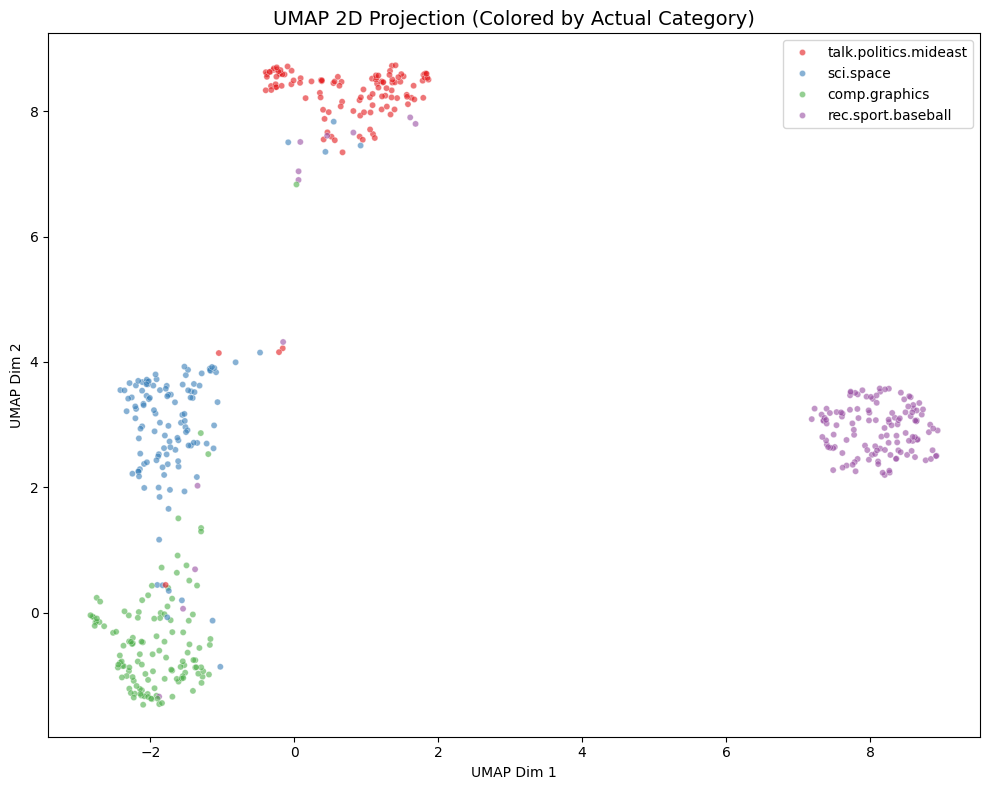

=> 같은 카테고리의 문서들이 가까이 모여 있는 것을 확인할 수 있습니다.
=> 임베딩이 문서의 의미를 잘 포착하고 있다는 증거입니다.


In [21]:
# UMAP 2차원 축소 결과를 산점도로 시각화합니다
# 실제 카테고리별로 색상을 구분하여 임베딩 품질을 확인합니다
df_umap_plot = pd.DataFrame({
    "UMAP Dim 1": embeddings_2d[:, 0],
    "UMAP Dim 2": embeddings_2d[:, 1],
    "category": [label_names[l] for l in sample_labels]
})

# seaborn의 hue 파라미터로 카테고리별 색상을 자동 구분합니다
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    data=df_umap_plot,
    x="UMAP Dim 1", y="UMAP Dim 2",
    hue="category",          # 카테고리별 색상 자동 구분
    palette="Set1",          # 색상 팔레트 (구분이 명확한 팔레트)
    alpha=0.6, s=20, ax=ax
)
ax.set_title("UMAP 2D Projection (Colored by Actual Category)", fontsize=14)
ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.show()

# 시각화 결과를 해석합니다
print("=> 같은 카테고리의 문서들이 가까이 모여 있는 것을 확인할 수 있습니다.")
print("=> 임베딩이 문서의 의미를 잘 포착하고 있다는 증거입니다.")

#### (3) HDBSCAN 군집화

**HDBSCAN이란?**

- **계층적 밀도 기반 클러스터링** 알고리즘 (Hierarchical Density-Based Spatial Clustering)
- K-Means와 달리 **군집 수를 미리 지정하지 않아도** 자동으로 결정합니다
- 어떤 군집에도 속하지 않는 문서는 **노이즈(label = -1)** 로 분류합니다
- 다양한 크기와 밀도의 군집을 잘 찾아냅니다

> **"계층적(Hierarchical)"이란?**
> HDBSCAN은 다양한 밀도 수준에서 군집을 탐색하여 **트리(계층 구조)를 만든 뒤,**
> 가장 안정적인 군집을 자동으로 선택합니다.
> 덕분에 밀도가 서로 다른 군집도 동시에 잘 찾아냅니다.

**K-Means vs HDBSCAN 비교**

| 항목 | K-Means | HDBSCAN |
|------|---------|--------|
| 군집 수 | **사전에 지정** (K) | **자동 결정** |
| 군집 형태 | 원형(구형)만 가능 | 불규칙한 형태도 가능 |
| 노이즈 처리 | 모든 점을 강제 배정 | 노이즈를 별도 분리 (-1) |
| 적합한 경우 | 군집 수를 알 때 | 군집 수를 모를 때 (토픽 모델링!) |

> **밀도 기반 군집화란?**
> 데이터가 **빽빽하게 모여 있는 영역** 을 하나의 군집으로 인식합니다.
> 반대로, 주변에 데이터가 적은 **고립된 점** 은 노이즈로 분류합니다.
> 쉽게 말해: "사람들이 많이 모여 있는 곳 = 군집, 혼자 떨어져 있는 사람 = 노이즈"

![HDBSCAN vs K-Means](images/3_hdbscan_vs_kmeans.png)

**HDBSCAN 파라미터 상세 설명:**

| 파라미터 | 의미 | 값이 작으면 | 값이 크면 |
|----------|------|------------|----------|
| `min_cluster_size` | 군집으로 인정되기 위한 **최소 문서 수** | 작은 군집도 포착 (토픽이 많아짐) | 큰 군집만 인정 (기준 미달 문서는 노이즈 처리) |
| `min_samples` | 핵심 포인트로 판정되기 위해 주변에 필요한 **최소 이웃 수** | 관대한 판정 (노이즈가 줄어듦) | 엄격한 판정 (이웃이 적은 점은 노이즈 처리) |

**파라미터 선택 가이드:**

| 목적 | `min_cluster_size` | `min_samples` | 결과 |
|------|-------------------|---------------|------|
| 세밀한 토픽 탐색 | 5~30 | 3~5 | 작은 군집도 인정 => 토픽이 많아지고 노이즈가 줄어듦 |
| 균형 (일반적 추천) | 30~80 | 5~10 | 적당한 토픽 수 + 적당한 노이즈 |
| 큰 토픽 위주 | 100~200 | *5~10* | 의미 있는 큰 토픽 위주로 추출, 소규모 군집은 노이즈 처리 |

**실무 튜닝 가이드:**

1. `min_cluster_size`부터 조정하세요 => 토픽이 너무 많으면 **높이고,** 너무 적으면 **낮추세요**
2. `min_samples`는 `min_cluster_size`의 1/10~1/3 수준으로 설정하세요 (예: clust=150이면 samp=5~50)
3. 노이즈가 너무 많으면(>30%) `min_samples`를 **낮추세요** (판정이 관대해짐)
4. 실험 순서: 먼저 기본값으로 실행 => 토픽 수와 노이즈 비율 확인 => 한 번에 **하나씩** 조정

> 처음부터 토픽 수를 줄이려고 `min_cluster_size`를 크게 잡기보다,\
> **세밀하게 많은 토픽을 먼저 뽑은 뒤** 유사한 토픽을 **병합(merge)** 하는 방식이 더 안전합니다. \
> 토픽 병합 방법은 **4회차(BERTopic 2/2)** 에서 다룹니다.

In [22]:
# HDBSCAN으로 UMAP 2D 결과를 군집화합니다
# metric: 점 간 거리를 계산하는 함수
#   - UMAP이 cosine 거리를 유클리디안 공간으로 재배치해주므로,
#     UMAP 축소 후에는 euclidean이 표준 선택입니다
hdbscan_model = HDBSCAN(
    min_cluster_size=10,  # 군집으로 인정되기 위한 최소 수
    min_samples=5,         # 핵심 포인트 판정
    metric="euclidean"     # UMAP 축소 후 저차원 공간이므로 유클리디안 거리 사용
)

# fit_predict()로 각 문서에 군집 라벨을 할당합니다
# -1은 노이즈(어떤 군집에도 속하지 않는 문서)를 의미합니다
cluster_labels = hdbscan_model.fit_predict(embeddings_2d)

# 군집화 결과를 집계합니다
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()

print("HDBSCAN 군집화 완료")
print(f"발견된 군집 수: {n_clusters}개")
print(f"노이즈 문서 수: {n_noise}건 ({n_noise / len(cluster_labels) * 100:.1f}%)")
print()

# 군집별 문서 수를 DataFrame으로 확인합니다
df_cluster_counts = pd.DataFrame(
    {"군집": [("노이즈" if l == -1 else f"군집 {l}") for l in sorted(set(cluster_labels))],
     "문서 수": [int((cluster_labels == l).sum()) for l in sorted(set(cluster_labels))]}
)

print("군집별 문서 수:")
display(df_cluster_counts)

HDBSCAN 군집화 완료
발견된 군집 수: 4개
노이즈 문서 수: 6건 (1.2%)

군집별 문서 수:


,군집,문서 수
0,노이즈,6
1,군집 0,127
2,군집 1,124
3,군집 2,113
4,군집 3,130


In [23]:
# 각 문서에 배정된 군집 라벨을 DataFrame으로 확인합니다
df_clusters = pd.DataFrame({
    "actual_category": [label_names[l] for l in sample_labels[:10]],
    "cluster_label": cluster_labels[:10],
    "umap_dim_1": embeddings_2d[:10, 0].round(3),
    "umap_dim_2": embeddings_2d[:10, 1].round(3),
})

print("문서별 군집 배정 결과 (상위 10건):")
print("cluster_label이 -1이면 노이즈(어떤 군집에도 속하지 않음)입니다")
display(df_clusters)

문서별 군집 배정 결과 (상위 10건):
cluster_label이 -1이면 노이즈(어떤 군집에도 속하지 않음)입니다


,actual_category,cluster_label,umap_dim_1,umap_dim_2
0,talk.politics.mideast,-1,-0.161,4.218
1,sci.space,2,-2.087,2.373
2,talk.politics.mideast,1,-0.136,8.585
3,comp.graphics,3,-1.969,-0.662
4,sci.space,2,-1.929,3.177
5,rec.sport.baseball,0,8.143,3.525
6,sci.space,2,-1.772,3.619
7,sci.space,1,0.433,7.351
8,sci.space,2,-1.747,1.657
9,talk.politics.mideast,1,0.400,8.022


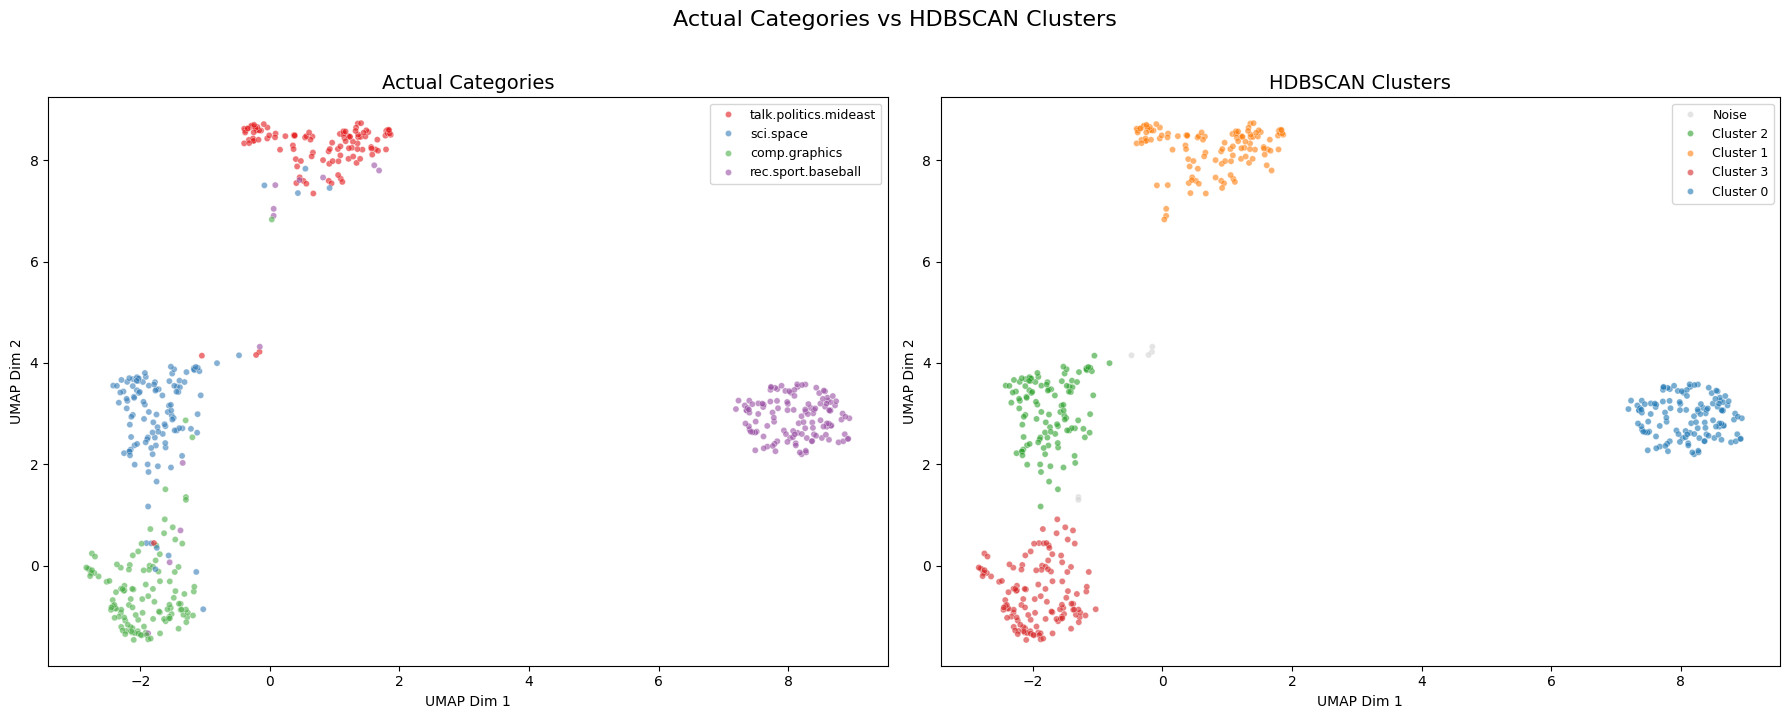

In [24]:
# 실제 카테고리와 HDBSCAN 군집 결과를 나란히 비교하는 산점도를 생성합니다
df_compare = pd.DataFrame({
    "UMAP Dim 1": embeddings_2d[:, 0],
    "UMAP Dim 2": embeddings_2d[:, 1],
    "category": [label_names[l] for l in sample_labels],
    "cluster": [f"Cluster {c}" if c != -1 else "Noise" for c in cluster_labels]
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 왼쪽: 실제 카테고리
sns.scatterplot(
    data=df_compare, x="UMAP Dim 1", y="UMAP Dim 2",
    hue="category", palette="Set1", alpha=0.6, s=20, ax=axes[0]
)
axes[0].set_title("Actual Categories", fontsize=14)
axes[0].legend(loc="best", fontsize=9)

# 오른쪽: HDBSCAN 군집 (노이즈는 회색으로 표시)
# 군집별 색상 팔레트를 생성합니다 (Noise는 lightgray)
cluster_names = sorted(df_compare["cluster"].unique())
cluster_palette = {name: "lightgray" if name == "Noise" else None for name in cluster_names}
non_noise = [n for n in cluster_names if n != "Noise"]
tab_colors = sns.color_palette("tab10", len(non_noise))
for name, color in zip(non_noise, tab_colors):
    cluster_palette[name] = color

sns.scatterplot(
    data=df_compare, x="UMAP Dim 1", y="UMAP Dim 2",
    hue="cluster", palette=cluster_palette, alpha=0.6, s=20, ax=axes[1]
)
axes[1].set_title("HDBSCAN Clusters", fontsize=14)
axes[1].legend(loc="best", fontsize=9)

plt.suptitle("Actual Categories vs HDBSCAN Clusters", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 4. BERTopic 모델 학습

위에서 임베딩 => UMAP => HDBSCAN을 **각각 따로 실행** 했습니다.

BERTopic은 이 3단계 + c-TF-IDF 키워드 추출까지 **한번에 실행** 합니다.

이제 **전체 데이터** (필터링 후 약 2,400건)에 BERTopic을 적용합니다.

In [25]:
# 전체 필터링된 문서에 대해 임베딩 벡터를 생성합니다
# 앞서 샘플 500건으로 원리를 파악했으므로, 이제 전체 데이터에 적용합니다
# (시간이 오래 걸리므로, 생성 후 파일로 저장해 두면 다음에 바로 로드할 수 있습니다)
import os

embedding_path = "data/all_embeddings.npy"

if os.path.exists(embedding_path):
    # 이미 저장된 임베딩 파일이 있으면 로드합니다 (시간 절약)
    all_embeddings = np.load(embedding_path)
    print(f"저장된 임베딩 로드 완료: {embedding_path}")
    print(f"임베딩 shape: {all_embeddings.shape}")
else:
    # 저장된 파일이 없으면 새로 생성합니다
    print(f"전체 {len(filtered_docs):,}건 문서 임베딩 생성 중...")
    all_embeddings = embedding_model.encode(filtered_docs, show_progress_bar=True)
    print(f"임베딩 완료: {all_embeddings.shape}")

    # 생성된 임베딩을 .npy 파일로 저장합니다 (다음 실행 시 로드하여 시간 절약)
    np.save(embedding_path, all_embeddings)
    print(f"임베딩 저장 완료: {embedding_path}")

저장된 임베딩 로드 완료: data/all_embeddings.npy
임베딩 shape: (3730, 384)


In [26]:
# BERTopic 모델을 생성하고 학습합니다

# [UMAP] 고차원 임베딩을 저차원으로 축소
umap_model = UMAP(
    n_components=5,      # 군집화 차원
    n_neighbors=30,      # 넓은 이웃 참조로 전역 구조 보존 
    min_dist=0.0,        # 군집이 빽빽하게 뭉치도록 설정
    metric="cosine",     # 임베딩 모델이 코사인 유사도로 훈련되었으므로 동일한 거리 함수 사용
    random_state=42
)

# [HDBSCAN] 밀도 기반 군집화
hdbscan_model = HDBSCAN(
    min_cluster_size=150,  # 군집으로 인정되기 위한 최소 문서 수
    min_samples=5,         # 핵심 포인트로 판정되기 위해 주변에 필요한 최소 이웃 수
    metric="euclidean"     # UMAP 축소 후 저차원 공간이므로 유클리디안 거리 사용
)

# [CountVectorizer] c-TF-IDF 키워드 추출의 1단계: 어떤 단어를 후보로 쓸지 결정
vectorizer_model = CountVectorizer(
    stop_words="english",  # 영어 불용어 제거
    ngram_range=(1, 2),    # 1~2단어 조합을 키워드 후보로 사용
    min_df=2,              # 최소 2개 문서에 등장해야 키워드 후보로 사용
    max_df=0.95            # 95% 이상 문서에 등장하면 제외 (너무 흔한 단어)
)

# [BERTopic] 모델을 조립합니다
topic_model = BERTopic(
    embedding_model=embedding_model,   # 임베딩 모델 (None이면 all-MiniLM-L6-v2 자동 사용)
    umap_model=umap_model,             # UMAP 차원 축소 모델
    hdbscan_model=hdbscan_model,       # HDBSCAN 군집화 모델
    vectorizer_model=vectorizer_model, # c-TF-IDF용 CountVectorizer
    language="english",                # 불용어 언어 (vectorizer_model 직접 지정 시 무시됨)
    # top_n_words=10,                    # 각 토픽에 표시할 대표 키워드 개수 (기본값:10)
    # nr_topics=5,                       # HDBSCAN 결과를 5개 토픽으로 병합 (유사 토픽 자동 통합)
    # calculate_probabilities=False,     # True이면 모든 토픽에 대한 확률 계산
    verbose=True                       # 각 단계 진행 상황 출력
)

# 전체 문서에 대해 토픽 모델링을 수행합니다
# 사전 계산된 임베딩을 전달하여 임베딩 단계를 건너뜁니다
print("BERTopic 모델 학습 중...")
# topics: 각 문서에 배정된 토픽 번호 (-1은 노이즈)
# probs: 각 문서가 배정된 토픽에 속할 확률 (1.0에 가까울수록 확실, 0에 가까울수록 경계에 걸침)
topics, probs = topic_model.fit_transform(filtered_docs, embeddings=all_embeddings)

print()
print(f"발견된 토픽 수: {len(set(topics)) - 1}개 (노이즈 제외)")
n_noise = topics.count(-1)
print(f"노이즈 문서 수: {n_noise}건 / 전체 {len(topics):,}건 ({n_noise / len(topics) * 100:.1f}%)")

2026-03-17 15:36:30,752 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


BERTopic 모델 학습 중...


2026-03-17 15:36:56,351 - BERTopic - Dimensionality - Completed ✓
2026-03-17 15:36:56,362 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-17 15:36:56,441 - BERTopic - Cluster - Completed ✓
2026-03-17 15:36:56,450 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-17 15:36:57,875 - BERTopic - Representation - Completed ✓



발견된 토픽 수: 5개 (노이즈 제외)
노이즈 문서 수: 105건 / 전체 3,730건 (2.8%)


In [27]:
# 각 문서에 어떤 토픽이 배정되었는지 샘플로 확인합니다
# topics 리스트에는 각 문서의 토픽 번호가 들어 있습니다 (-1은 노이즈)
df_topic_sample = pd.DataFrame({
    "actual_category": [label_names[l] for l in filtered_labels],
    "assigned_topic": topics,
    "prob": probs,
    "text_preview": [doc.replace('\n', ' ') for doc in filtered_docs]
})

print("문서별 토픽 배정 결과 (10건):")
display(df_topic_sample.sample(10))

문서별 토픽 배정 결과 (10건):


,actual_category,assigned_topic,prob,text_preview
3625,talk.politics.mideast,3,0.564592,If you think that kind of uncalled for blanket...
2982,sci.space,1,0.791266,Exactly. Some of the SPACE:1999 effects remain...
2691,rec.sport.baseball,2,0.758308,You want to speed up ballgames? 1. Enforce t...
1173,rec.sport.baseball,2,0.758308,Me too! I would like any park or action gif o...
2087,comp.graphics,0,0.952401,I was chaining around in the anonymous ftp wor...
1874,talk.politics.mideast,4,1.000000,Subject: Re: NETTEKI BUTUN VATANSEVERLERE DUYU...
73,sci.space,1,0.681585,Bill says ... I presume the one you refer to...
230,comp.graphics,0,0.862126,A while back someone had several equations whi...
2780,talk.politics.mideast,3,1.000000,"After reading the first paragraph, a quick sca..."
694,sci.space,1,1.000000,McDonnell Douglas rolls out DC-X ... SS...


#### c-TF-IDF란?

BERTopic의 4번째 단계인 c-TF-IDF는 **각 토픽(군집)의 대표 키워드** 를 찾아주는 핵심 알고리즘입니다.

**기존 TF-IDF 복습:**
- TF (Term Frequency): 단어가 **문서 안에서** 얼마나 자주 나오는가
- IDF (Inverse Document Frequency): 그 단어가 **전체 문서에서** 얼마나 드문가
- TF-IDF = TF x IDF => "이 문서를 대표하는 단어"에 높은 점수

**c-TF-IDF (Class-based TF-IDF):**
- 개별 문서가 아닌 **토픽(군집) 단위** 로 TF-IDF를 계산합니다
- 같은 토픽의 모든 문서를 **하나의 큰 문서** 로 합친 뒤 TF-IDF를 적용합니다
- 결과: 각 토픽을 가장 잘 설명하는 키워드 + 점수

| 구분 | TF-IDF | c-TF-IDF |
|------|--------|----------|
| 분석 단위 | 개별 문서 | 토픽(군집) 전체 |
| 목적 | 문서별 핵심 단어 | 토픽별 대표 키워드 |
| 결과 | 문서를 대표하는 단어 | 토픽을 특징짓는 단어 |

In [28]:
# 토픽 요약 정보를 확인합니다
# get_topic_info()는 각 토픽의 번호, 문서 수, 대표 키워드를 포함한 데이터프레임을 반환합니다
# 토픽 -1은 노이즈(어떤 토픽에도 배정되지 않은 문서)를 의미합니다
topic_info = topic_model.get_topic_info()

print("토픽 요약 테이블 (토픽 -1은 노이즈):")
print("=" * 70)
display(topic_info)

토픽 요약 테이블 (토픽 -1은 노이즈):


,Topic,Count,Name,Representation,Representative_Docs
0,-1,105,-1_hacker_graphics_comp_ics uci,"[hacker, graphics, comp, ics uci, uci, uci edu...","[This sounds wonderful, but it seems no one ei..."
1,0,943,0_graphics_jpeg_images_format,"[graphics, jpeg, images, format, ftp, data, gi...",[Archive-name: jpeg-faq\nLast-modified: 18 Apr...
2,1,889,1_nasa_launch_shuttle_mission,"[nasa, launch, shuttle, mission, satellite, so...",[Archive-name: space/references\nLast-modified...
3,2,878,2_game_games_baseball_hit,"[game, games, baseball, hit, players, 03, 02, ...","[NOTE: Saturday, April 20th's scores should be..."
4,3,697,3_israel_israeli_jews_arab,"[israel, israeli, jews, arab, jewish, arabs, p...",[From: Center for Policy Research <cpr>\nSubje...
5,4,218,4_armenian_armenians_turkish_turkey,"[armenian, armenians, turkish, turkey, armenia...",[Since your criminal grandparents ruthlessly e...


In [29]:
# 주요 토픽의 대표 키워드를 DataFrame으로 확인합니다
# get_topic()은 각 토픽의 키워드와 c-TF-IDF 점수를 반환합니다 (점수 내림차순 정렬)

result = topic_model.get_topic(1)
print("첫번째 토픽의 keyword 별 c-TF-IDF점수:")
pprint(result)
print()

topic_ids = [t for t in topic_info["Topic"] if t != -1]

# 토픽별 상위 5개 키워드를 표 형태로 정리합니다
rows = []
for topic_id in topic_ids[:10]:
    keywords = topic_model.get_topic(topic_id)
    count = topic_info[topic_info["Topic"] == topic_id]["Count"].values[0]
    row = {"토픽": topic_id, "문서 수": count}
    for i, (word, score) in enumerate(keywords[:5]):
        row[f"키워드 {i+1}"] = f"{word} ({score:.4f})"
    rows.append(row)

df_topics = pd.DataFrame(rows).set_index("토픽")

print("주요 토픽별 대표 키워드 (상위 10개 토픽 x 상위 5개 키워드):")
display(df_topics)

첫번째 토픽의 keyword 별 c-TF-IDF점수:
[('nasa', 0.03332799279309766),
 ('launch', 0.028181178791928867),
 ('shuttle', 0.023210516543787148),
 ('mission', 0.02050378362042885),
 ('satellite', 0.020239649425970212),
 ('solar', 0.020089798206976404),
 ('spacecraft', 0.01983887128277745),
 ('data', 0.01784643381336627),
 ('mars', 0.015016080816960622),
 ('venus', 0.014856645489830572)]

주요 토픽별 대표 키워드 (상위 10개 토픽 x 상위 5개 키워드):


,문서 수,키워드 1,키워드 2,키워드 3,키워드 4,키워드 5
토픽,,,,,,
0,943,graphics (0.0477),jpeg (0.0474),images (0.0322),format (0.0298),ftp (0.0279)
1,889,nasa (0.0333),launch (0.0282),shuttle (0.0232),mission (0.0205),satellite (0.0202)
2,878,game (0.0565),games (0.0411),baseball (0.0393),hit (0.0356),players (0.0342)
3,697,israel (0.0723),israeli (0.0482),jews (0.0415),arab (0.0402),jewish (0.0341)
4,218,armenian (0.0645),armenians (0.0567),turkish (0.0485),turkey (0.0293),armenia (0.0286)


In [30]:
# 토픽 1의 대표 문서를 확인합니다
# get_representative_docs()는 해당 토픽의 c-TF-IDF 벡터와
# 코사인 유사도가 가장 높은 문서를 반환합니다 (기본 3건, BERTopic 모델 생성 시 nr_repr_docs로 변경 가능)
# 즉, 토픽에 속한 전체 문서가 아니라 "이 토픽을 가장 잘 대표하는 문서"입니다

# 토픽 1의 대표 문서
representative_docs = topic_model.get_representative_docs(1)

# 긴 텍스트도 잘리지 않고 전체 표시되도록 설정합니다
pd.set_option("display.max_colwidth", 500)

df_repr = pd.DataFrame({
    "doc": range(1, len(representative_docs) + 1),
    "text_preview": representative_docs
})

print("[토픽 1] 대표 문서 예시:")
display(df_repr)

[토픽 1] 대표 문서 예시:


,doc,text_preview
0,1,"Archive-name: space/references\nLast-modified: $Date: 93/04/01 14:39:21 $\n\nREFERENCES ON SPECIFIC AREAS\n\n PUBLISHERS OF SPACE/ASTRONOMY MATERIAL\n\n Astronomical Society of the Pacific\n 1290 24th Avenue\n San Francisco, CA 94122\n\n\tMore expensive but better organized slide sets.\n\n Cambridge University Press\n 32 East 57th Street\n New York, NY 10022\n\n Crawford-Peters Aeronautica\n P.O. Box 152528\n San Diego, CA 92115\n (619) 287-3933\n\n\tAn excel..."
1,2,"Archive-name: space/acronyms\nEdition: 8\n\nAcronym List for sci.astro, sci.space, and sci.space.shuttle:\nEdition 8, 1992 Dec 7\nLast posted: 1992 Aug 27\n\nThis list is offered as a reference for translating commonly appearing\nacronyms in the space-related newsgroups. If I forgot or botched your\nfavorite acronym, please let me know! Also, if there's an acronym *not*\non this list that confuses you, drop me a line, and if I can figure\nit out, I'll add it to the list.\n\nNote that this ..."
2,3,"This file and other text and image files from JPL missions are\navailable from the JPL Info public access computer site,\nreachable by Internet via anonymous ftp to pubinfo.jpl.nasa.gov\n(128.149.6.2); or by dialup modem to +1 (818) 354-1333, up to\n9600 bits per second, parameters N-8-1.\n-----------------------------------------------------------------\n\nOur Solar System at a Glance\n\nInformation Summary \nPMS 010-A (JPL)\nJune 1991\n\nJPL 410-34-1 6/91\n\nNASA\nNational Aeronautics and..."


#### BERTopic 결과 2D 시각화

전체 문서의 토픽 배정 결과를 **2차원 산점도** 로 시각화합니다.
앞서 샘플 500건으로 했던 것과 동일하게 UMAP 2D 축소를 적용하되, 이번에는 **전체 데이터** 를 대상으로 합니다.

In [33]:
df.head()

,강아지를 키우고 싶다,개를 키우고 싶다,고양이를 키우고 싶다,주은님은 열심히 공부를 한다,강아지를 산책시켜야 한다,호롤롤롤롤로
강아지를 키우고 싶다,0.000000,0.208896,0.281373,0.295466,0.263254,0.447753
개를 키우고 싶다,0.208896,0.000000,0.286865,0.330668,0.339223,0.419131
고양이를 키우고 싶다,0.281373,0.286865,0.000000,0.414773,0.425991,0.466852
주은님은 열심히 공부를 한다,0.295466,0.330668,0.414773,0.000000,0.320538,0.497225
강아지를 산책시켜야 한다,0.263254,0.339223,0.425991,0.320538,0.000000,0.452984


저장된 2D 임베딩 로드 완료: data/all_embeddings_2d.npy
shape: (3730, 2)


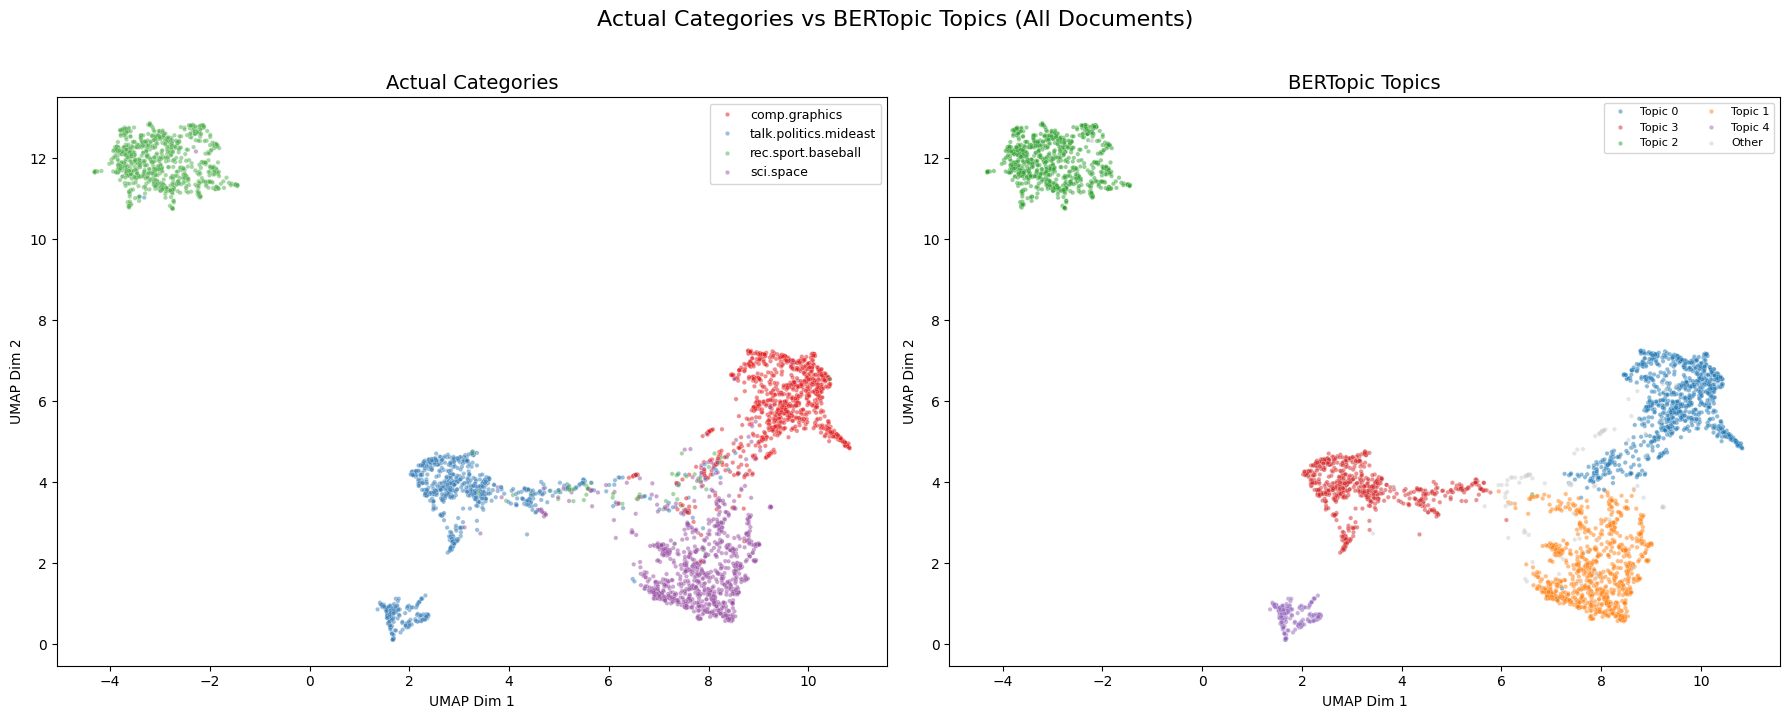

In [38]:
# 전체 임베딩을 2차원으로 축소합니다 (시각화 전용)
# BERTopic 내부 UMAP과 동일한 metric/n_neighbors를 사용하되, 2차원으로 축소합니다
import os

embeddings_2d_path = "data/all_embeddings_2d.npy"

if os.path.exists(embeddings_2d_path):
    # 이미 저장된 2D 임베딩이 있으면 로드합니다 (시간 절약)
    all_embeddings_2d = np.load(embeddings_2d_path)
    print(f"저장된 2D 임베딩 로드 완료: {embeddings_2d_path}")
    print(f"shape: {all_embeddings_2d.shape}")
else:
    # 저장된 파일이 없으면 UMAP 2D 축소를 수행합니다
    umap_2d_all = UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )

    print("전체 문서 UMAP 2D 축소 중...")
    all_embeddings_2d = umap_2d_all.fit_transform(all_embeddings)
    print(f"축소 완료: {all_embeddings_2d.shape}")

    # 다음 실행 시 바로 로드할 수 있도록 저장합니다
    np.save(embeddings_2d_path, all_embeddings_2d)
    print(f"저장 완료: {embeddings_2d_path}")

# 시각화용 DataFrame을 생성합니다
df_viz = pd.DataFrame({
    "UMAP Dim 1": all_embeddings_2d[:, 0],
    "UMAP Dim 2": all_embeddings_2d[:, 1],
    "topic": [f"Topic {t}" if t != -1 else "Noise" for t in topics]
})

# 실제 카테고리 vs BERTopic 토픽 비교 산점도를 생성합니다
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 왼쪽: 실제 카테고리
df_viz["category"] = df["category"].values
sns.scatterplot(
    data=df_viz, x="UMAP Dim 1", y="UMAP Dim 2",
    hue="category", palette="Set1", alpha=0.5, s=10, ax=axes[0]
)
axes[0].set_title("Actual Categories", fontsize=14)
axes[0].legend(loc="best", fontsize=9)

# 오른쪽: BERTopic 토픽 (상위 토픽만 색상, 나머지+노이즈는 회색)
top_topics = [f"Topic {t}" for t in topic_info["Topic"].values[1:11]]  # 상위 10개 토픽
df_viz["topic_color"] = df_viz["topic"].apply(lambda x: x if x in top_topics else "Other")

# 색상 팔레트 설정 (Other는 회색)
palette = {t: c for t, c in zip(top_topics, sns.color_palette("tab10", len(top_topics)))}
palette["Other"] = (0.8, 0.8, 0.8)

sns.scatterplot(
    data=df_viz.sort_values("topic_color", key=lambda x: x == "Other"),
    x="UMAP Dim 1", y="UMAP Dim 2",
    hue="topic_color", palette=palette, alpha=0.5, s=10, ax=axes[1]
)
axes[1].set_title("BERTopic Topics", fontsize=14)
axes[1].legend(loc="best", fontsize=8, ncol=2)

plt.suptitle("Actual Categories vs BERTopic Topics (All Documents)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 5. 정리 및 핵심 요약

**이번 실습에서 배운 내용**

1. **임베딩**: 텍스트를 숫자 벡터로 변환 => 의미적 유사도를 수치화
2. **UMAP**: 고차원 벡터를 저차원으로 압축 => 군집화 성능 향상 및 시각화 가능
3. **HDBSCAN**: 밀도 기반 군집화 => 토픽 수를 자동 결정하고 노이즈를 분리
4. **BERTopic**: 위 3단계 + c-TF-IDF를 통합하여 토픽과 대표 키워드를 한번에 도출

**토픽 해석 방법:**
1. **키워드 확인**: `get_topic(topic_id)` => 대표 키워드와 c-TF-IDF 점수를 확인합니다
2. **대표 문서 확인**: `get_representative_docs(topic_id)` => 실제 문서를 읽어 주제를 파악합니다
3. **토픽 이름 붙이기**: 키워드와 문서를 보고 **분석자가 직접** 이름을 붙입니다 (예: "우주 과학", "야구")

> 모델은 키워드만 추출하고, **토픽의 이름과 의미는 사람이 해석** 합니다!

---

**다음 시간 예고:** BERTopic 토픽 모델링 (2/2)에서는 **하이퍼파라미터 튜닝, 자동 축소(reduce_topics), 키워드 개선(KeyBERTInspired), 인터랙티브 시각화** 를 다룹니다.